In [1]:
from music21 import *
import pandas as pd

/Users/skye/.cache/uv/archive-v0/0woMiqm0BCKIsVKkpcGVe/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
def count_notes_played(input):
    total = 0
    for n in input.recurse().notes:
        if n.tie and n.tie.type != "start":
            continue
        if len(n.expressions) and type(n.expressions[0]) is expressions.Tremolo:
            if n.expressions[0]._numberOfMarks != 1:
                print("Unhandled: tremolo notation with >1 slash")
            total += 2
        else:
            total += 1
    return total

In [3]:
# 1. Fantasie (8 minutes) Georges Hüe (1913)
# https://musescore.com/user/33794713/scores/25570873 - downloaded just flute out of full orch score
# 
score1 = converter.parse('./assets/fantaisie-pour-flute-et-orchestra-georges-hue.mxl').getElementsByClass(stream.Part).first()
# score1.show()

In [4]:
df_results = pd.DataFrame([["Fantasie", "Georges Hüe", 8, count_notes_played(score1), "🤖"]], index=[1],
                          columns=["Composition", "Composer", "Duration [min]", "Note count", "Labeler"])
# df_results

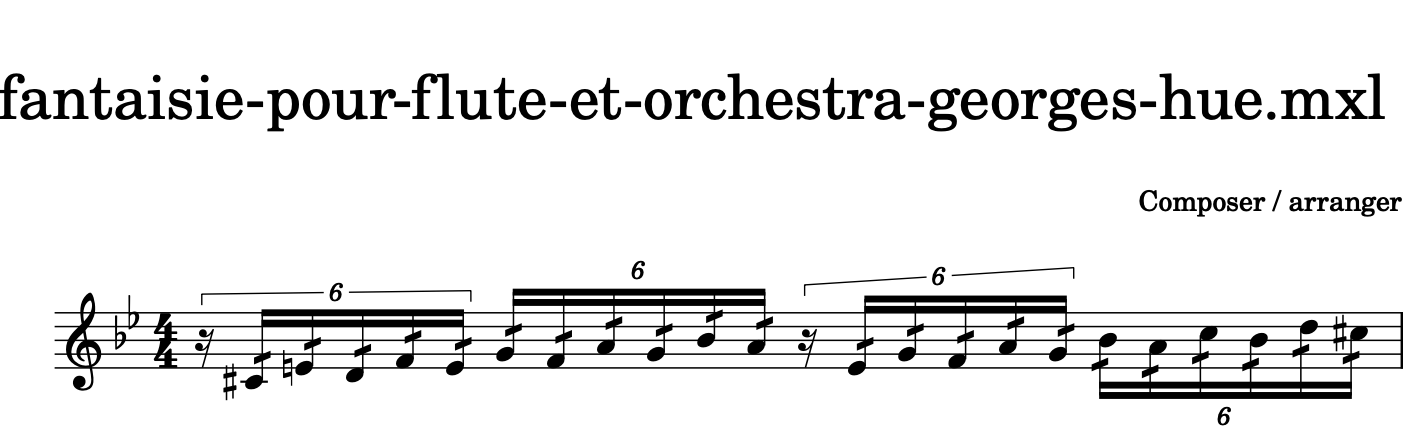

44

In [5]:
# Thanks to this bar, we updated our note counting algorithm to include (notated as tremolos in 🤖)
score1.measures(15,15).show()
count_notes_played(score1.measures(15,15))

In [6]:
# 2. Fantasie, Op. 38, No. 3 (12 minutes) Friedrich Kuhlau (1821)
#   I. Adagio – Allegro vivace
#   II. Romanza con variazioni
# https://musescore.com/user/23784/scores/7034227
# Used MuseScore to remove third movement, saved as mxl file
#
score2 = converter.parse('./assets/trois-fantaisies-op-38-flute-f-kuhlau_mvmt1and2.mxl').getElementsByClass(stream.Part).first()
# score2.show()

df_results.loc[2] = ["Fantasie, Op. 38, No. 3, Movements I and II", 
                     "Friedrich Kuhlau", 12, 
                     count_notes_played(score2), "🤖"]
# df_results

In [7]:
# 3. Romance in f minor, Op. 11 (10 minutes) Antonín Dvořák (1877)
#   (arr. Robert Stallman)
#
score3 = converter.parse('./assets/romance-in-f-minor-for-piano-and-violin-antonin-dvorak.mxl').getElementsByClass(stream.Part).first()
# score3.show()

df_results.loc[3] = ["Romance in f minor, Op. 11", 
                     "Antonín Dvořák", 10, 
                     count_notes_played(score3), "🤖"]
# df_results

In [8]:
# score3.measures(100, 103).show()

In [9]:
# 4. Fantasy Pieces, Op. 2 (5 minutes) Carl Nielsen (1889)
#   I. Romanze (arr. James Galway & Toke Lund Christiansen)
#   II. Humoresque
#
mvmt_1_af = 150 + 118 + 161 + 42
mvmt_2_af = 145 + 98

df_results.loc[4] = ["Fantasy Pieces, Op. 2, Mvmts I and II", 
                     "Carl Nielsen", 5, 
                     mvmt_1_af + mvmt_2_af, "AF"]
# df_results

In [10]:
# 5. Fantastiestücke, Op. 73 (11 minutes) Robert Schumann (1849)
#   I. Zart und mit Ausdruck
#   II. Lebhaft, Leicht
#   III. Rasch und mit Feuer
# https://musescore.com/user/37403731/scores/10973164

score5 = converter.parse('./assets/fantasiestucke-op73-robert-schumann.mxl').getElementsByClass(stream.Part).first()
# score5.show()

df_results.loc[5] = ["Fantastiestücke, Op. 73, Mvmts I, II, III", 
                     "Robert Schumann", 11, 
                     count_notes_played(score5), 
                      "🤖"]
# df_results

In [11]:
# 6. Drei Romanzen, Op. 22 (10 minutes) Clara Schumann (1853)
#   I. Andante molto - https://musescore.com/user/38235231/scores/8399499
#   II. Allegretto   
#   III. Leidenschaftlich schnell

score6_mvmt_1 = converter.parse('./assets/three-romances-clara-schumann_i.mxl').getElementsByClass(stream.Part).first()
# score6_mvmt_1.show()

# Counted from https://musescore.com/user/97106398/scores/19547617 (can't download mxl without paying more)
mvmt_2_hr = 191 + 214
mvmt_3_hr = 154 + 176

df_results.loc[6] = ["Drei Romanzen, Op. 22", 
                     "Clara Schumann", 10, 
                     count_notes_played(score6_mvmt_1) + mvmt_2_hr + mvmt_3_hr, 
                     "🤖/HR"]
# df_results

In [12]:
# 7. Fantasy for Flute and Piano (6 minutes, world premiere) Francine Trester (2025)

# No score available!

df_results.loc[7] = ["Fantasy for Flute and Piano (world premiere)", 
                     "Francine Trester", 6, 
                     0, #count_notes_played(score7), 
                     "-"] # "🤖"]
# df_results

In [13]:
# 8. Romance, Op. 41 (5 minutes) Georges Brun (1905)
# https://musescore.com/user/23784/scores/31436735
# 
score8 = converter.parse('./assets/romance-op-41-georges-brun.mxl').getElementsByClass(stream.Part).first()
# score8.show().measures(1,36) # measure 37 has some issue where it doesn't want to display, poking at it shows the counting function works fine

df_results.loc[8] = ["Romance, Op. 41", 
                     "Georges Brun", 5, 
                     count_notes_played(score8), 
                    "🤖"]
# df_results

In [14]:
# 9. A Day of Promise (1 minute, world premiere) Fred Harris (2025)
#
# No score available!

df_results.loc[9] = ["A Day of Promise", 
                     "Fred Harris", 1, 
                     0, #count_notes_played(score9), 
                     "-"]
# df_results

In [15]:
# 10. Fantasy for Flute, Op. 89 (6 minutes) Malcom Arnold (1966)
# https://www.scribd.com/doc/131953855/Arnold-Fantasy-for-Flute-Solo-Op-89#start_trial
# No musicxml; printed and counted by hand

score10_count = 304 + 359 + 362 + 343

df_results.loc[10] = ["Fantasy for Flute, Op. 89", 
                     "Malcom Arnold", 6, 
                     score10_count,
                     "HR"]
# df_results

In [16]:

# 11. Fantasie (7 minutes) Philippe Gaubert (1912)
#
score11 = converter.parse('./assets/fantaisie-philippe-gaubert.mxl').getElementsByClass(stream.Part).first()
# score11.show()

df_results.loc[11] = ["Fantasie", 
                     "Philippe Gaubert", 7, 
                     count_notes_played(score11), 
                     "🤖"]
# df_results

In [25]:
df_publish = df_results[["Labeler", "Composer", "Composition",  "Duration [min]", "Note count"]]
df_publish['Avg. NPM'] = df_publish['Note count'] /  df_publish['Duration [min]']
df_publish

,Labeler,Composer,Composition,Duration [min],Note count,Avg. NPM
1,🤖,Georges Hüe,Fantasie,8,290,36.250000
2,🤖,Friedrich Kuhlau,"Fantasie, Op. 38, No. 3, Movements I and II",12,5253,437.750000
3,🤖,Antonín Dvořák,"Romance in f minor, Op. 11",10,1115,111.500000
4,AF,Carl Nielsen,"Fantasy Pieces, Op. 2, Mvmts I and II",5,714,142.800000
5,🤖,Robert Schumann,"Fantastiestücke, Op. 73, Mvmts I, II, III",11,1021,92.818182
6,🤖/HR,Clara Schumann,"Drei Romanzen, Op. 22",10,983,98.300000
7,-,Francine Trester,Fantasy for Flute and Piano (world premiere),6,0,0.000000
8,🤖,Georges Brun,"Romance, Op. 41",5,517,103.400000
9,-,Fred Harris,A Day of Promise,1,0,0.000000
10,HR,Malcom Arnold,"Fantasy for Flute, Op. 89",6,1368,228.000000


In [22]:
# Total note count
int(df_publish['Note count'].sum())

12489

In [23]:
# Total play duration (min)
int(df_publish['Duration [min]'].sum())

81

In [26]:
print(df_publish.to_markdown(index=False))

| Labeler   | Composer         | Composition                                  |   Duration [min] |   Note count |   Avg. NPM |
|:----------|:-----------------|:---------------------------------------------|-----------------:|-------------:|-----------:|
| 🤖        | Georges Hüe      | Fantasie                                     |                8 |          290 |    36.25   |
| 🤖        | Friedrich Kuhlau | Fantasie, Op. 38, No. 3, Movements I and II  |               12 |         5253 |   437.75   |
| 🤖        | Antonín Dvořák   | Romance in f minor, Op. 11                   |               10 |         1115 |   111.5    |
| AF        | Carl Nielsen     | Fantasy Pieces, Op. 2, Mvmts I and II        |                5 |          714 |   142.8    |
| 🤖        | Robert Schumann  | Fantastiestücke, Op. 73, Mvmts I, II, III    |               11 |         1021 |    92.8182 |
| 🤖/HR     | Clara Schumann   | Drei Romanzen, Op. 22                        |               10 |          983 |   